In [1]:
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pickle
from sklearn.linear_model import LinearRegression
from config import *
import os
import scienceplots
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei' # 使用黑体
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号
import warnings
warnings.filterwarnings("ignore")

In [1]:
# plt.style.reload_library()
# plt.style.use(['science', 'no-latex', 'cjk-sc-font'])
plt.rcParams.update({
    'figure.dpi': 200,
    # 统一字体：SimHei支持中文，Times兼容英文负号（无冲突）
    # 'font.family': ['SimHei', 'Times New Roman'],
    'font.size': 20,
    'legend.fontsize': 18,
    'lines.linewidth': 7,
    'ytick.labelsize': 20,
    'xtick.labelsize': 20,
    'savefig.bbox': 'tight',
    # 核心：关闭Unicode负号，用ASCII减号（解决负号显示）
    # 'axes.unicode_minus': False
})
plt.rcParams['font.family'] = 'SimHei' # 使用黑体
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号
import warnings
warnings.filterwarnings("ignore")

# 加载数据

In [2]:
data = pd.read_csv(f"./{prefix}clean_data.csv", parse_dates=[date_col])
df = data[data[date_col]=='2021-04-30'].reset_index(drop=True)
df.head()

,datetime,instrument,行业,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,...,营业利润增速,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值
0,2021-04-30,000001.SZ,银行,-0.065289,-0.264463,-0.194215,-0.307025,-0.760508,-0.715480,-0.661839,...,-0.155305,-0.253301,-2.879738,-1.910580,-1.085132,-0.892965,2.988508,0.069248,-0.849078,2.125154
1,2021-04-30,000002.SZ,房地产,-0.108240,-0.258427,-0.317978,-0.232959,-0.723554,-0.731905,-0.400749,...,-0.145442,0.030250,-2.879738,-1.883657,-0.275748,-0.763107,2.988508,-1.045061,-0.802901,2.125154
2,2021-04-30,000004.SZ,计算机,0.157107,0.200125,0.046758,0.372818,0.525832,-0.599197,2.729929,...,2.105901,2.257934,-1.222422,1.543871,-0.899922,-0.647437,-0.619757,0.908605,-0.037256,-0.814874
3,2021-04-30,000005.SZ,公用事业,0.074286,0.365714,0.251429,0.280000,0.672376,-0.567701,0.235171,...,-1.957226,-1.339165,-1.128023,-0.109381,-0.502410,0.604914,-0.098383,-1.101415,-0.725505,-0.594829
4,2021-04-30,000006.SZ,房地产,-0.047529,-0.138783,-0.207224,-0.138783,-0.710645,-0.920516,-0.143263,...,-0.126723,-1.249434,-2.879738,-0.356910,-0.510070,-0.252890,-0.219453,-1.167332,-0.780266,0.411093


In [3]:
df.shape

(4267, 25)

In [4]:
factors_data = df[factors_lst]

# K-means Clustering

In [5]:
from scipy.spatial.distance import pdist, cdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.decomposition import PCA

## 肘部法

<Figure size 800x550 with 0 Axes>

Text(0.5, 0, '簇类')

Text(0, 0.5, '平均euclidean距离')

<Figure size 800x550 with 0 Axes>

Text(0.5, 0, '簇类')

...

Text(0.5, 0, '簇类')

Text(0, 0.5, '平均chebyshev距离')

<Figure size 800x550 with 0 Axes>

Text(0.5, 0, '簇类')

Text(0, 0.5, '平均minkowski距离')

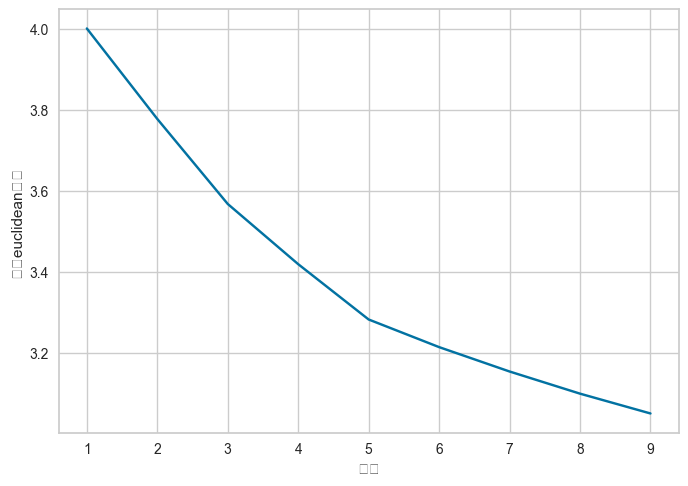

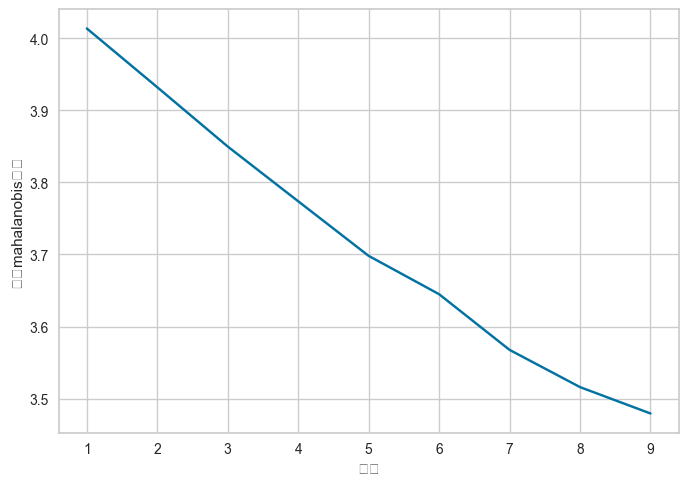

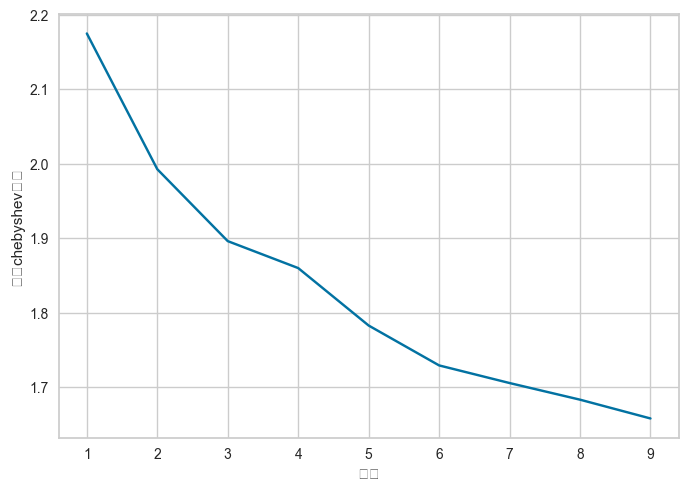

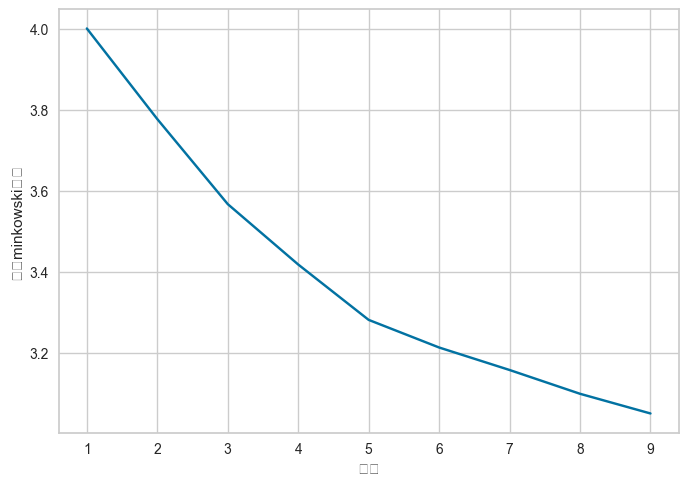

In [6]:
clusters=range(1, 10)
for dismetrics in ['euclidean', 'mahalanobis', 'chebyshev', 'minkowski']:
    meanDistance = []
    for k in clusters:
        model = KMeans(n_clusters=k)
        _ = model.fit(factors_data)
        prediction = model.predict(factors_data)
        # 距离测度
        distance = sum(np.min(cdist(factors_data, model.cluster_centers_, dismetrics), axis=1)) / factors_data.shape[0]
        meanDistance.append(distance)
        # print("簇类数 = {}, silhouette score: {})".format(k, distance))
    plt.figure()
    plt.plot(clusters, meanDistance, 'bx-')
    plt.xlabel('簇类')
    plt.ylabel(f'平均{dismetrics}距离')

In [7]:
# import sklearn
# sklearn.metrics.pairwise.pairwise_distances()
# ['braycurtis', 'canberra', 'chebyshev',
#   'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis',
#   'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean',
#   'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

In [11]:
# 计算从每个点到其指定中心的平方距离之和
for dismetrics in ['euclidean', 'manhattan']:
    visualizer = KElbowVisualizer(model, k=(2, 12), distance_metric=dismetrics)
    visualizer.fit(factors_data)
    # visualizer.show()
    visualizer.show(generateFilePath(f'elbow_{dismetrics}'), clear_figure=True)

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=11), k=(2, 12))

<Axes: >

KElbowVisualizer(ax=<Axes: >, distance_metric='manhattan',
                 estimator=KMeans(n_clusters=11), k=(2, 12))

<Axes: >

<Figure size 1600x1100 with 0 Axes>

## silhoutte score

簇类数 = 2, silhouette score: 0.1996388122296293)
簇类数 = 3, silhouette score: 0.20277178716007918)
簇类数 = 4, silhouette score: 0.1937131553524722)
簇类数 = 5, silhouette score: 0.13907379379195672)
簇类数 = 6, silhouette score: 0.09637814608184707)
簇类数 = 7, silhouette score: 0.10237287041988832)
簇类数 = 8, silhouette score: 0.10522347317828265)
簇类数 = 9, silhouette score: 0.10297919154784843)


<Figure size 2000x1200 with 0 Axes>

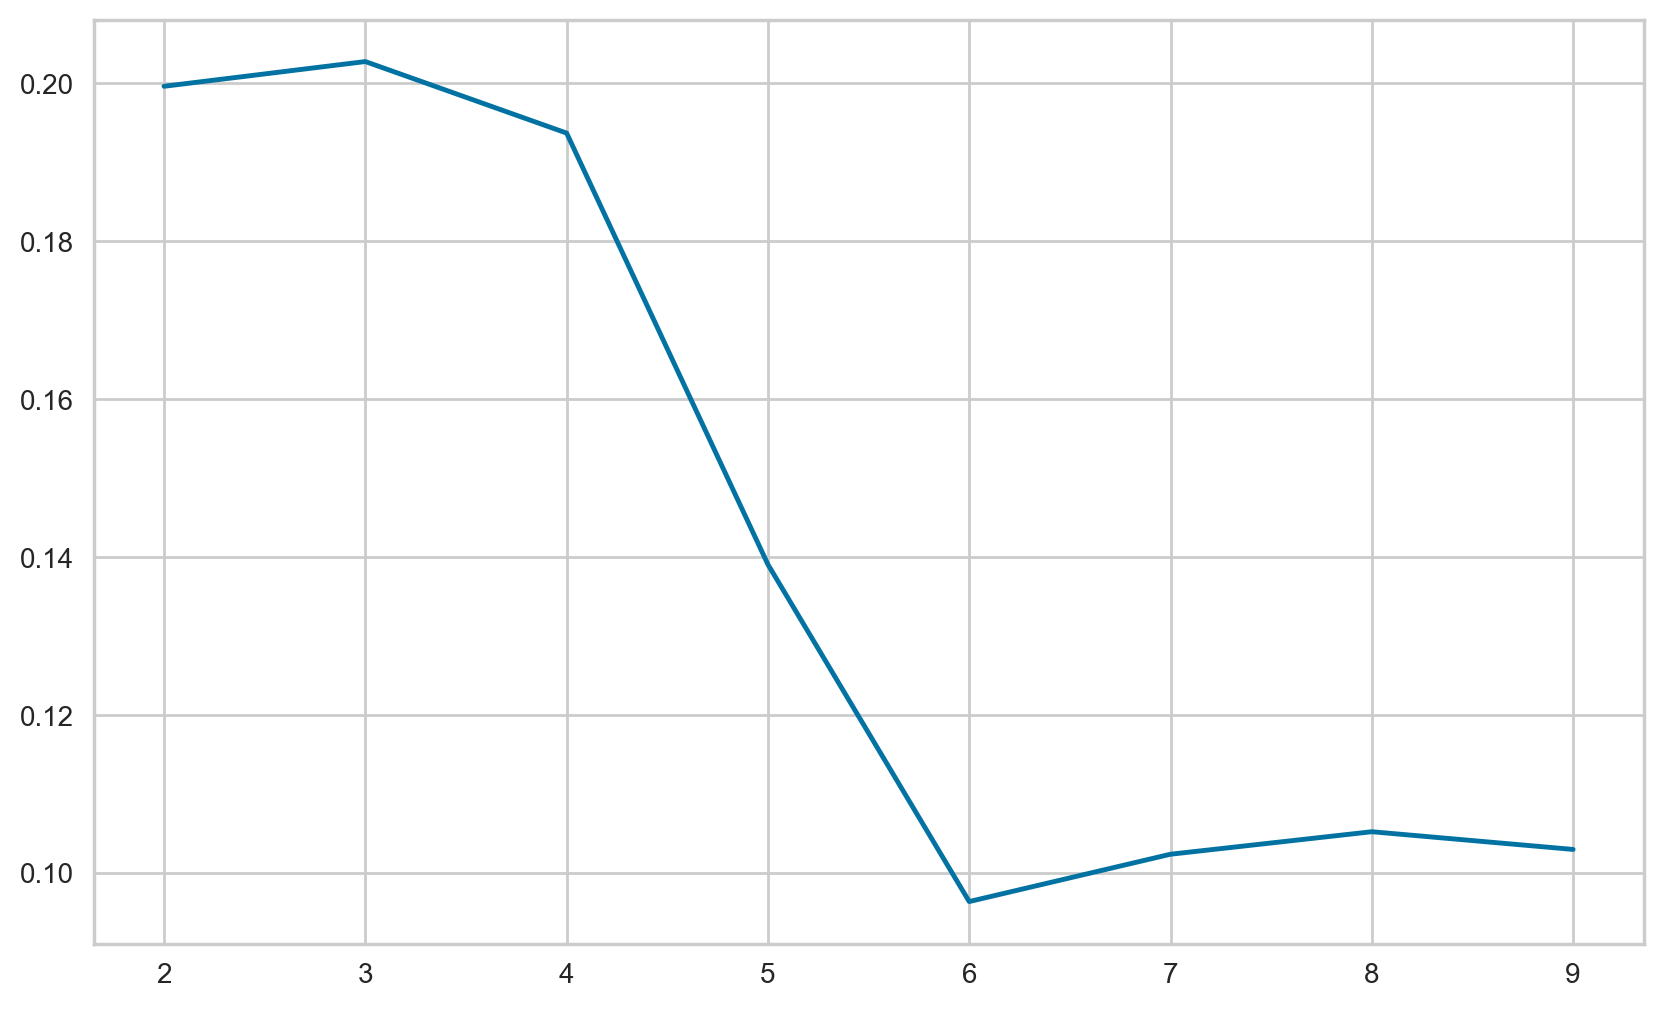

In [12]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((factors_data))
    #centers = clusterer.cluster_centers_
    score = silhouette_score(factors_data, preds)
    sil_score.append(score)
    print("簇类数 = {}, silhouette score: {})".format(n_clusters, score))
plt.figure(figsize=(10, 6))
plt.plot(cluster_list, sil_score)
plt.savefig(generateFilePath('silscoretrend'))

## 轮廓系数

SilhouetteVisualizer(ax=<Axes: >,
                     estimator=KMeans(n_clusters=4, random_state=1))

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4267 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

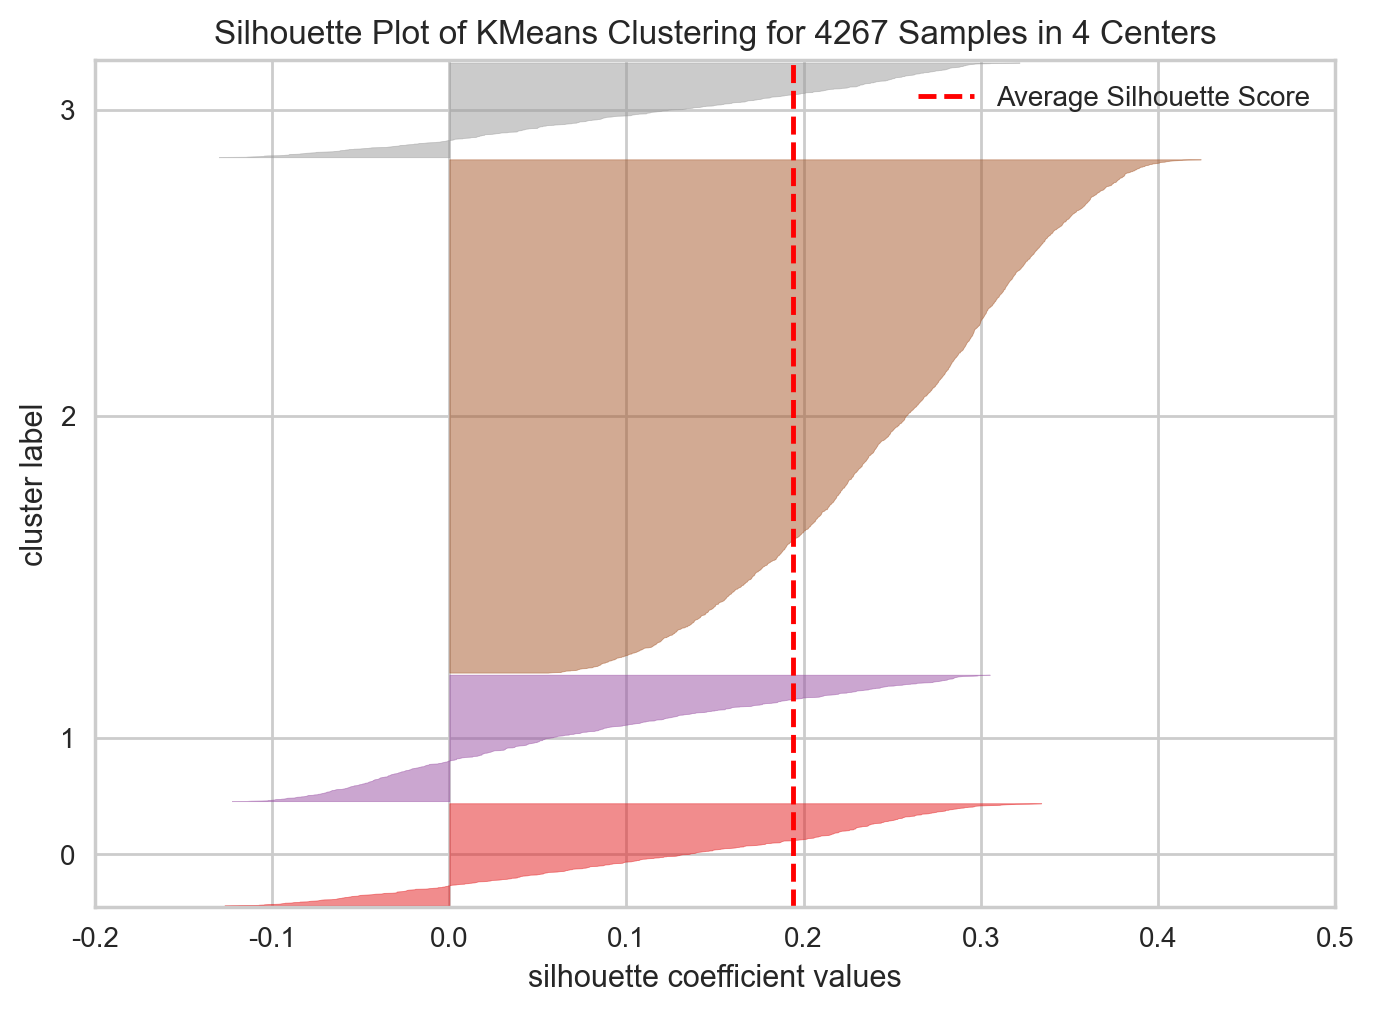

In [13]:
visualizer = SilhouetteVisualizer(KMeans(4, random_state = 1))
visualizer.fit(factors_data)  
visualizer.show(generateFilePath('silscore4'))

SilhouetteVisualizer(ax=<Axes: >,
                     estimator=KMeans(n_clusters=5, random_state=1))

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4267 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

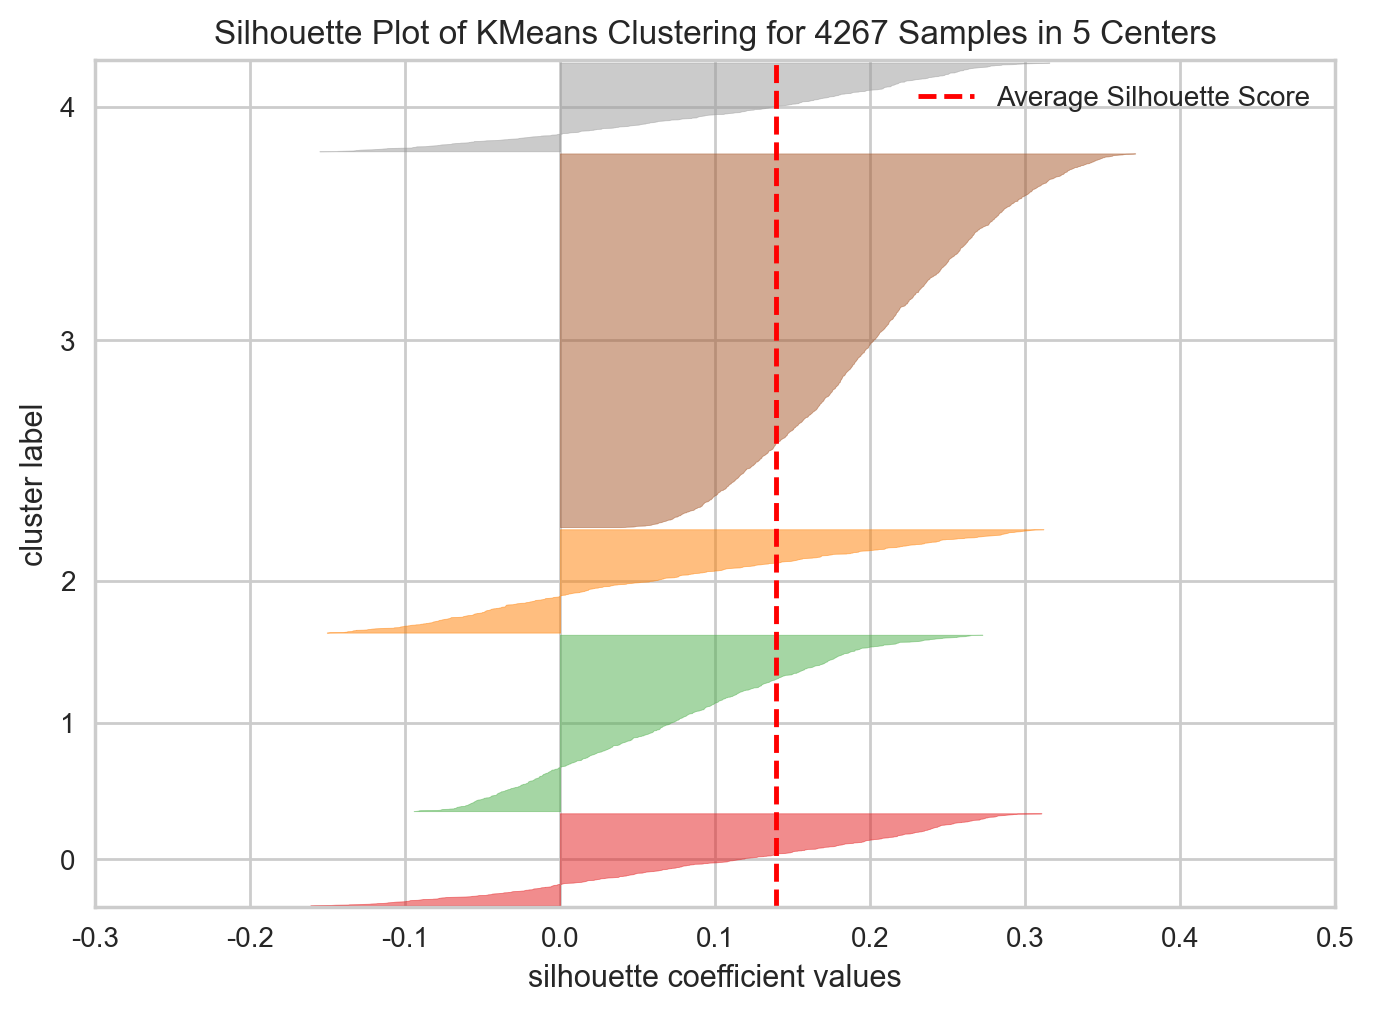

In [16]:
visualizer = SilhouetteVisualizer(KMeans(5, random_state = 1))
visualizer.fit(factors_data) 
visualizer.show(generateFilePath('silscore5'))

SilhouetteVisualizer(ax=<Axes: >,
                     estimator=KMeans(n_clusters=6, random_state=1))

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4267 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

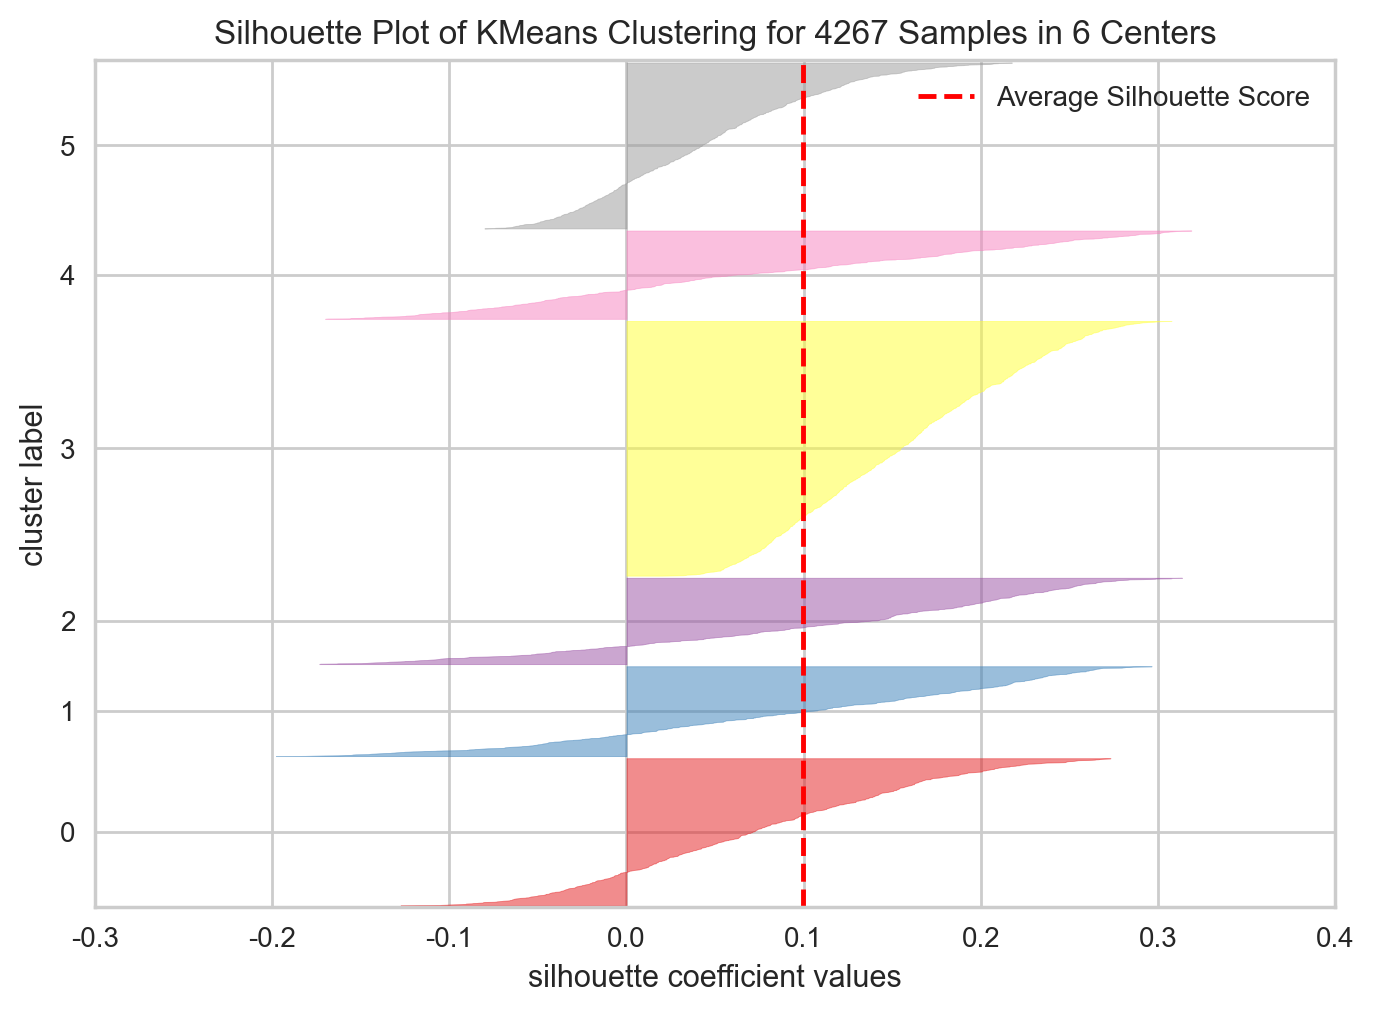

In [15]:
visualizer = SilhouetteVisualizer(KMeans(6, random_state = 1))
visualizer.fit(factors_data)    
visualizer.show(generateFilePath('silscore6'))

## clusters = 4 样本分布

In [6]:
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(factors_data)
df['KMeans_Clusters'] = kmeans.labels_
factors_data['KMeans_Clusters'] = kmeans.labels_
cluster_profile = df.groupby('KMeans_Clusters').mean()
cluster_profile['count_in_each_segments'] = df.groupby('KMeans_Clusters')[industry_col].count().values
cluster_profile

KMeans(n_clusters=4, random_state=0)

,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,市盈率,市销率,涨跌幅,...,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值,count_in_each_segments
KMeans_Clusters,,,,,,,,,,,,,,,,,,,,,
0,-0.017954,-0.000232,-0.070253,-0.022281,2.124493,0.120904,0.096757,0.105408,0.118987,0.165015,...,0.004995,0.565228,0.358500,0.127226,0.464699,0.316126,1.489181,2.081351,-0.766827,524
1,0.013656,0.105194,0.055492,0.129731,-0.373772,-0.389764,-0.177628,-0.040495,-0.370998,-0.194931,...,0.027467,-0.063338,-0.095070,-0.009727,-0.153549,-0.026734,-0.422318,-0.362003,0.096878,2616
2,0.046357,0.053431,0.010129,-0.049627,-0.218450,1.526051,0.877193,1.009687,1.351299,0.706831,...,0.570144,-0.081151,0.563658,0.379218,-0.187915,-0.315364,0.364655,-0.179135,0.542910,643
3,0.050767,0.127130,0.082042,0.181804,0.010363,-0.051615,-0.310044,-1.236628,0.081191,-0.064093,...,-0.911311,-0.161791,-0.623106,-0.588961,0.576468,0.221206,0.185910,-0.058769,-0.414683,484


In [7]:
df['KMeans_Clusters'].value_counts()

1    2616
2     643
0     524
3     484
Name: KMeans_Clusters, dtype: int64

In [22]:
sns.axes_style({"font.sans-serif":['Times']})
sns.set_theme(style="whitegrid",font_scale=1.7)
plt.rcParams['font.family'] = 'SimHei' # 使用黑体
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

{'font.sans-serif': ['Times']}

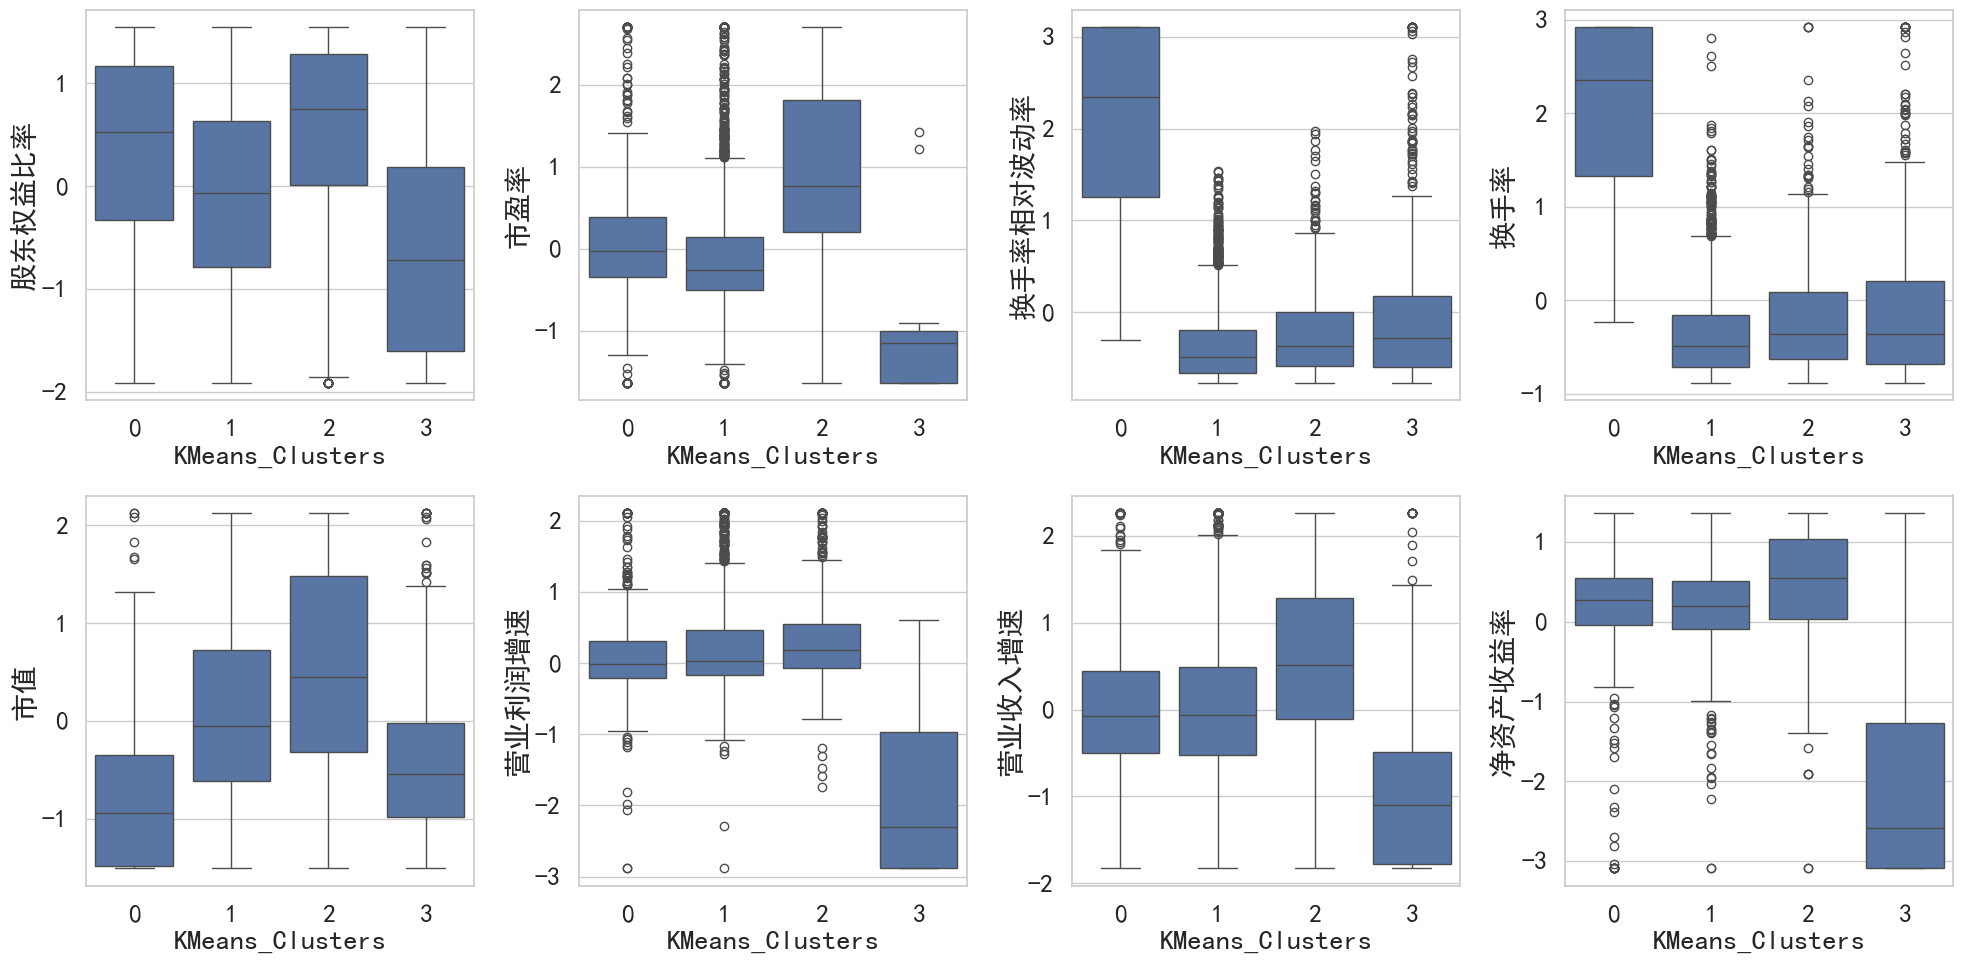

In [38]:
selected_factors_lst = [ "股东权益比率", "市盈率", #"市净率", "市现率",
 "换手率相对波动率", "换手率", "市值", 
 "营业利润增速", "营业收入增速", "净资产收益率"]
rownums = int(np.ceil(len(selected_factors_lst)//4))
fig, axes = plt.subplots(rownums, 4,  figsize=(20, 10))
# fig.suptitle('Boxplot of numerical variables for each cluster', fontsize=20)
counter = 0
for ii in range(rownums):
    for jj in range(4):
        if counter == len(selected_factors_lst):
            continue
        _ = sns.boxplot(ax=axes[ii, jj],y=factors_data[selected_factors_lst[counter]],
                        x=factors_data['KMeans_Clusters'])
        counter = counter+1
fig.tight_layout(pad=1)
plt.savefig(generateFilePath('kmeansboxplot'), dpi=200)

In [19]:
pd.crosstab(df[industry_lst].values.flatten(), df["KMeans_Clusters"]).style.highlight_max(color = 'lightgreen', axis = 0)

KMeans_Clusters,0,1,2,3
row_0,,,,
交通运输,5,96,5,15
休闲服务,4,15,3,15
传媒,10,87,20,54
公用事业,37,131,4,17
农林牧渔,15,53,13,13
化工,46,258,59,30
医药生物,45,167,121,37
商业贸易,5,73,3,14
国防军工,7,50,22,6


# DBSCAN

In [27]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [28]:
# import sklearn
# sklearn.metrics.pairwise.pairwise_distances()
# ['braycurtis', 'canberra', 'chebyshev',
#   'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis',
#   'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean',
#   'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

## clusters = 4 样本分布

In [29]:
dbscan = DBSCAN(eps=0.4, min_samples=50)
dbscan.fit(factors_data)
df['DBSCAN_segments'] = dbscan.labels_
np.unique(dbscan.labels_)
factors_data['DBSCAN_segments'] = dbscan.labels_
cluster_profile = df.groupby('DBSCAN_segments').mean()
cluster_profile['count_in_each_segments'] = df.groupby('DBSCAN_segments')[industry_col].count().values
cluster_profile

DBSCAN(eps=0.4, min_samples=50)

array([-1], dtype=int64)

,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,市盈率,市销率,涨跌幅,...,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值,KMeans_Clusters,count_in_each_segments
DBSCAN_segments,,,,,,,,,,,,,,,,,,,,,
-1,0.018911,0.086936,0.036226,0.089942,-2.796867e-15,-1.912331e-15,9.943385e-16,1.181983e-15,2.111583e-15,9.198141e-17,...,1.183750e-14,1.410277e-14,-2.706374e-15,-7.758838e-15,-4.180262e-15,6.546595e-15,6.991777e-16,9.321409e-14,1.254746,4267


# 层次聚类

## 距离和链接方式

In [30]:
distance_metrics = ["euclidean"] # "chebyshev", "mahalanobis", "cityblock"
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(factors_data, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(factors_data))
        print("CPCC: 距离测度-{} 链接-{}".format(dm.capitalize(), lm, c))
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

CPCC: 距离测度-Euclidean 链接-single
CPCC: 距离测度-Euclidean 链接-complete
CPCC: 距离测度-Euclidean 链接-average
CPCC: 距离测度-Euclidean 链接-centroid
CPCC: 距离测度-Euclidean 链接-ward
CPCC: 距离测度-Euclidean 链接-weighted


In [31]:
high_cophenet_corr
high_dm_lm[0].capitalize()
high_dm_lm[1]

0.7736036619709445

'Euclidean'

'average'

## 链接方式对聚类的影响

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Dendrogram (Single Linkage)')

Text(0.8, 0.8, 'Cophenetic\nCorrelation\n0.68')

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Dendrogram (Complete Linkage)')

...

Text(0.5, 1.0, 'Dendrogram (Ward Linkage)')

Text(0.8, 0.8, 'Cophenetic\nCorrelation\n0.66')

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Dendrogram (Weighted Linkage)')

Text(0.8, 0.8, 'Cophenetic\nCorrelation\n0.67')

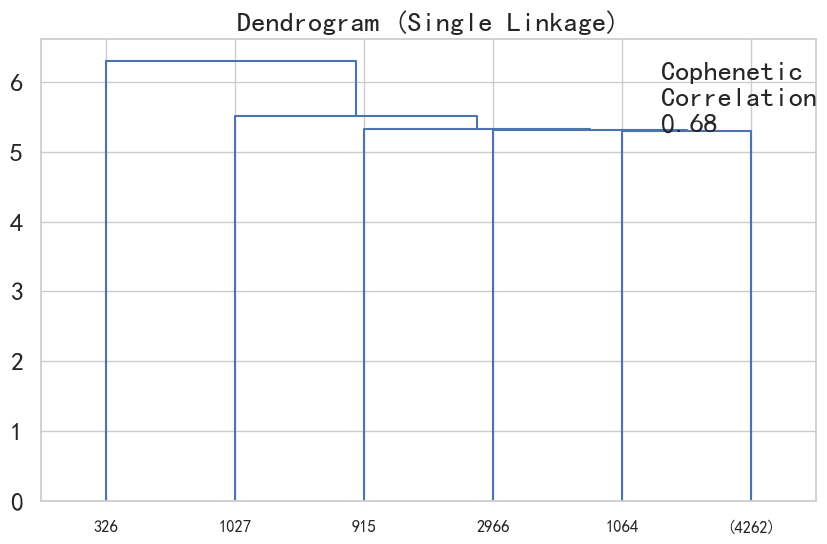

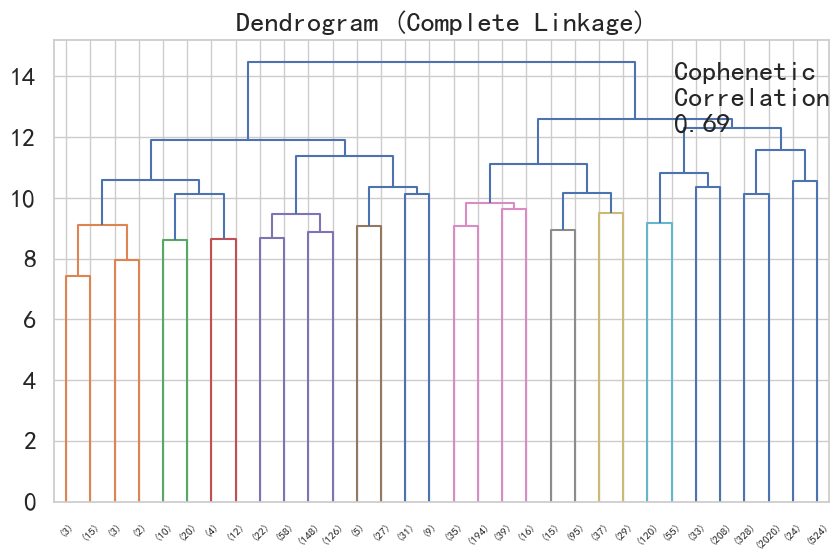

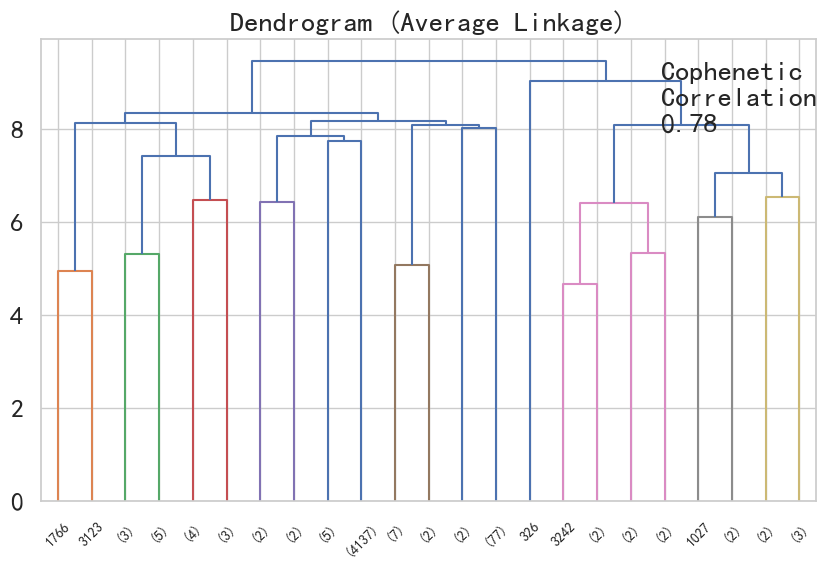

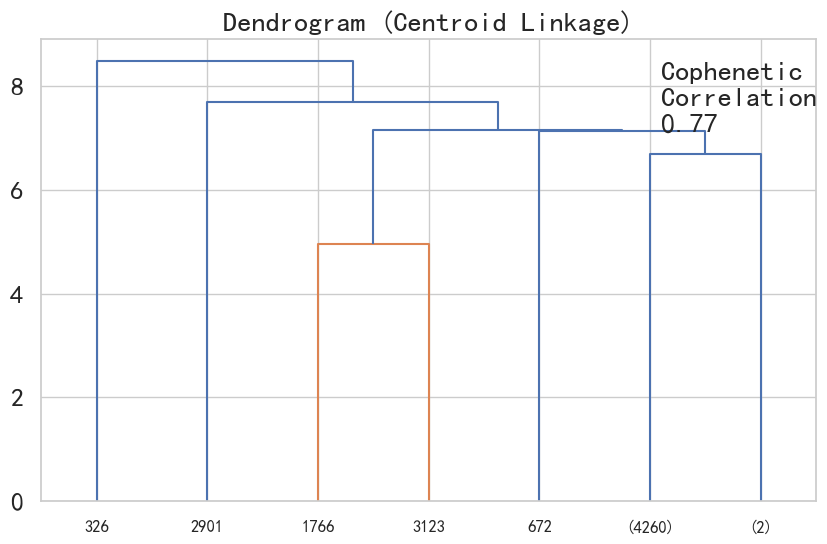

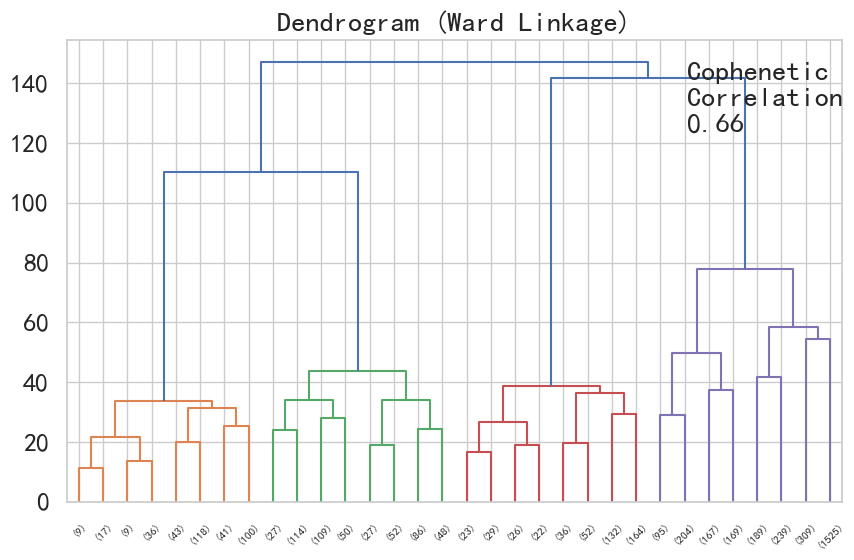

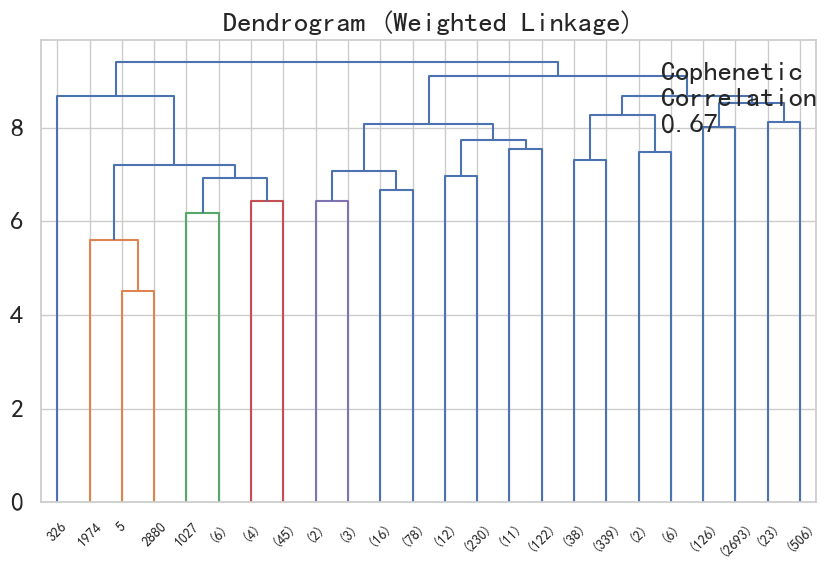

In [40]:
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]
# compare_cols = ["Linkage", "Cophenetic Coefficient"]

for i, method in enumerate(linkage_methods):
    Z = linkage(factors_data, metric="euclidean", method=method)
    plt.figure(figsize=(10, 6))
    _ = dendrogram(Z, truncate_mode='level', p=4)
    plt.title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(factors_data))
    plt.annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )
    plt.savefig(generateFilePath(f"hc_{method}"), bbox_inches='tight')

In [33]:
HCmodel = AgglomerativeClustering(n_clusters=4, affinity="euclidean", linkage="ward")
HCmodel.fit(factors_data)

factors_data["HC_Clusters"] = HCmodel.labels_
df["HC_Clusters"] = HCmodel.labels_

cluster_profile = df.groupby("HC_Clusters").mean()

cluster_profile["count_in_each_segments"] = (
    df.groupby("HC_Clusters")[industry_lst].count().values
)
cluster_profile

AgglomerativeClustering(affinity='euclidean', n_clusters=4)

,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,市盈率,市销率,涨跌幅,...,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值,KMeans_Clusters,DBSCAN_segments,count_in_each_segments
HC_Clusters,,,,,,,,,,,,,,,,,,,,,
0,0.016868,0.105409,0.053101,0.117528,-0.345011,-0.283565,-0.099347,0.059022,-0.226185,-0.118201,...,-0.035144,-0.026721,-0.125446,-0.014602,-0.341662,-0.326386,0.111067,1.077321,-1.0,2897
1,0.049099,0.125295,0.078620,0.180236,0.019403,0.011307,-0.277459,-1.238655,0.064780,-0.028436,...,-0.649760,-0.565248,0.572351,0.233374,0.217717,-0.048277,-0.387557,2.969008,-1.0,484
2,-0.011329,0.001812,-0.064931,-0.013232,2.095132,0.147963,0.124524,0.104644,0.142328,0.022035,...,0.457853,0.120003,0.343764,0.086705,1.377561,1.996616,-0.898283,0.111111,-1.0,513
3,0.037200,0.010758,-0.010728,-0.099576,-0.227073,1.984211,0.960367,1.004935,1.476919,0.924631,...,0.486373,0.775954,-0.241155,-0.308663,0.476489,-0.148409,0.875696,1.981233,-1.0,373


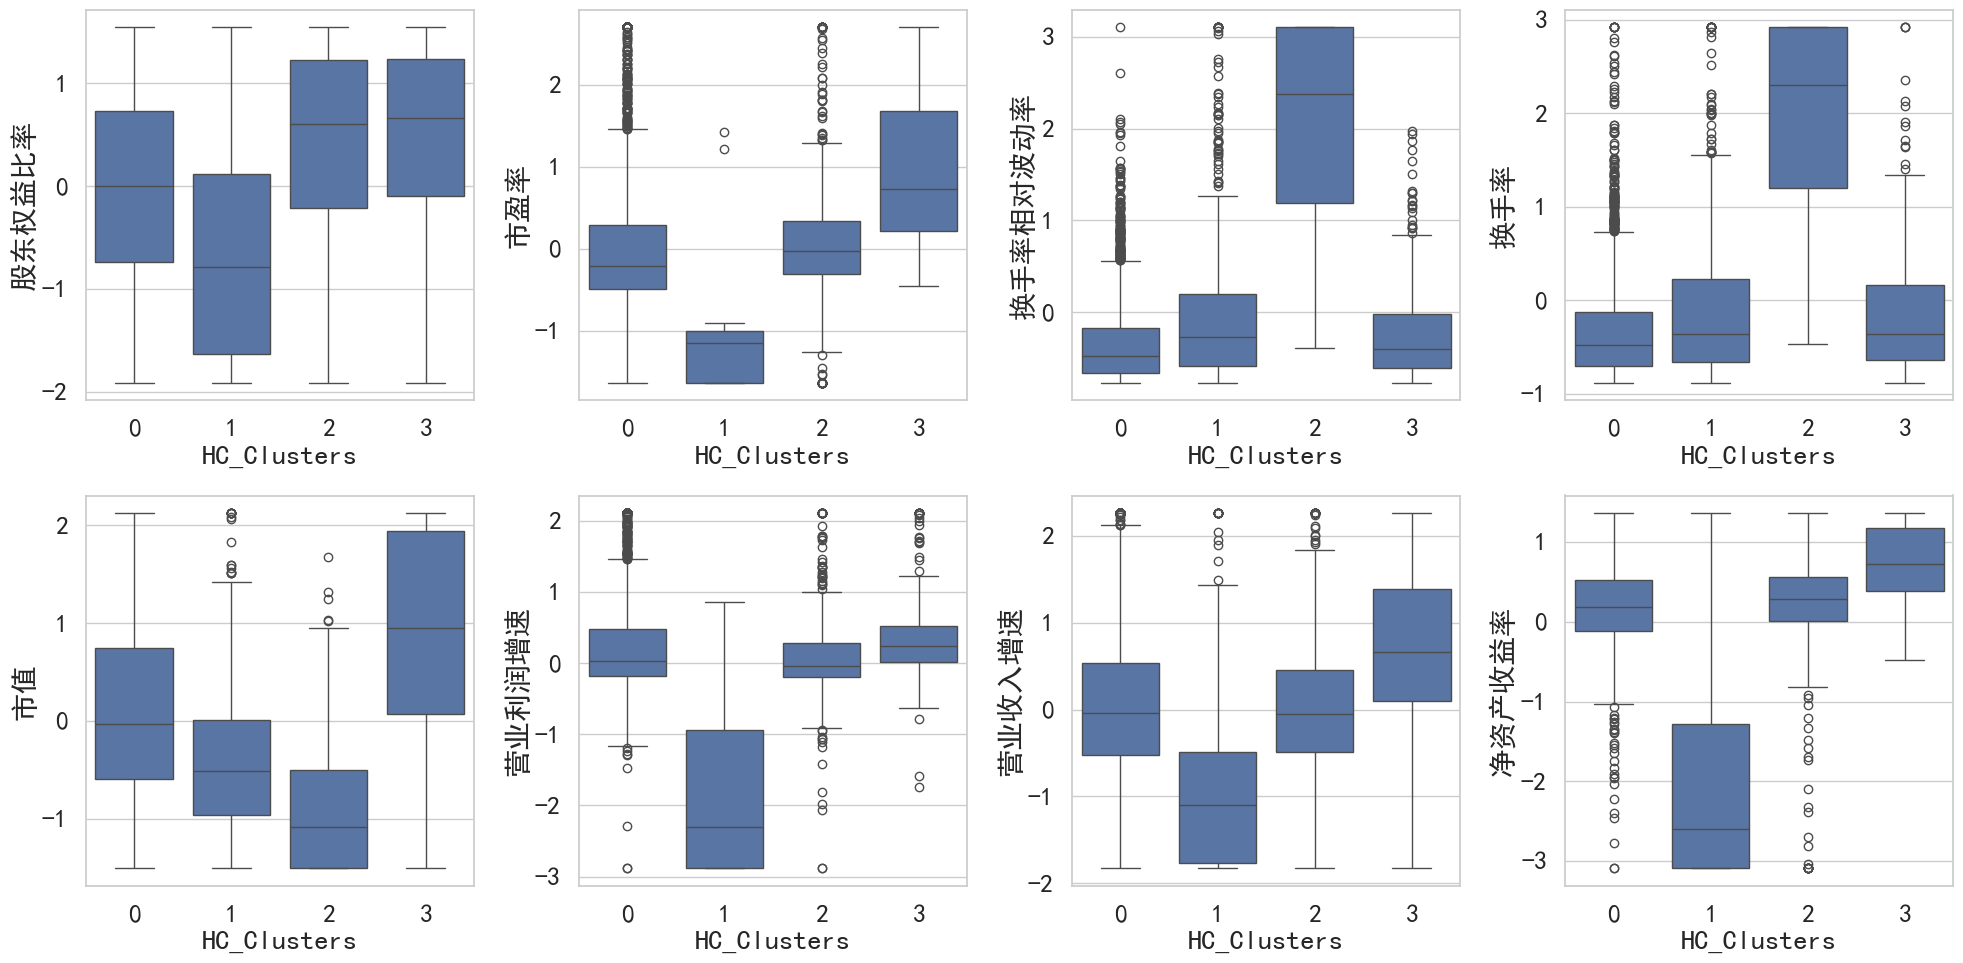

In [37]:
selected_factors_lst = [ "股东权益比率", "市盈率", #"市净率", "市现率",
 "换手率相对波动率", "换手率", "市值", 
 "营业利润增速", "营业收入增速", "净资产收益率"]
rownums = int(np.ceil(len(selected_factors_lst)//4))
fig, axes = plt.subplots(rownums, 4,  figsize=(20, 10))
counter = 0
for ii in range(rownums):
    for jj in range(4):
        if counter == len(selected_factors_lst):
            continue
        _ = sns.boxplot(ax=axes[ii, jj],y=factors_data[selected_factors_lst[counter]],x=factors_data['HC_Clusters'])
        counter = counter+1
fig.tight_layout(pad=1)
plt.savefig(generateFilePath('hcboxplot'), dpi=200)

In [53]:
pd.crosstab(df[industry_lst].values.flatten(), df["HC_Clusters"]).style.highlight_max(color = 'lightgreen', axis = 0)

HC_Clusters,0,1,2,3
row_0,,,,
交通运输,92,6,18,5
休闲服务,13,3,20,1
传媒,81,23,59,8
公用事业,132,7,18,32
农林牧渔,55,13,15,11
化工,249,67,31,46
医药生物,157,125,43,45
商业贸易,70,2,17,6
国防军工,47,28,6,4


In [54]:
pd.crosstab(df.KMeans_Clusters, df.HC_Clusters).style.highlight_max(color = 'lightgreen', axis = 0)
pd.crosstab(df.KMeans_Clusters, df.HC_Clusters).to_csv("聚类效果.csv")

HC_Clusters,0,1,2,3
KMeans_Clusters,,,,
0,7,598,6,36
1,46,18,13,445
2,2419,111,66,19
3,5,0,474,4


# PCA降维（用于可视化）

In [41]:
pca = PCA(n_components=2)

X_reduced_pca = pca.fit_transform(factors_data)
reduced_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

In [42]:
pca.explained_variance_ratio_.sum()

0.35324875472559025

<Axes: xlabel='Component 1', ylabel='Component 2'>

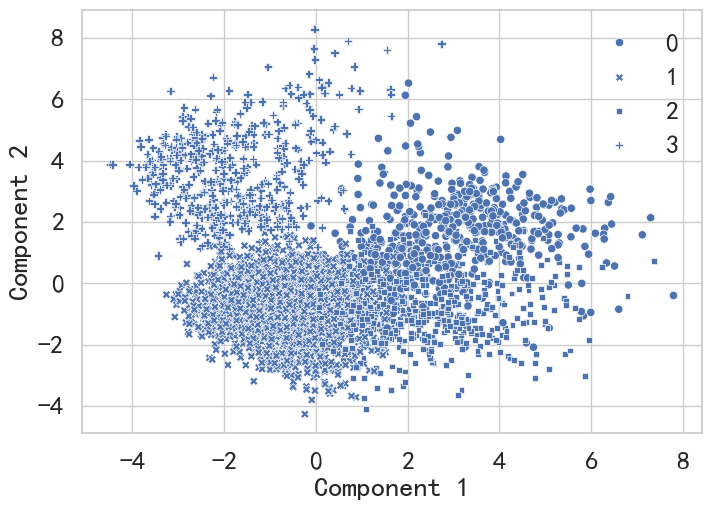

In [44]:
# KMeans
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    # hue=df["KMeans_Clusters"],
    palette="rainbow",
    style=df["KMeans_Clusters"]
)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(generateFilePath('kmeanspca'), bbox_inches='tight')

<Axes: xlabel='Component 1', ylabel='Component 2'>

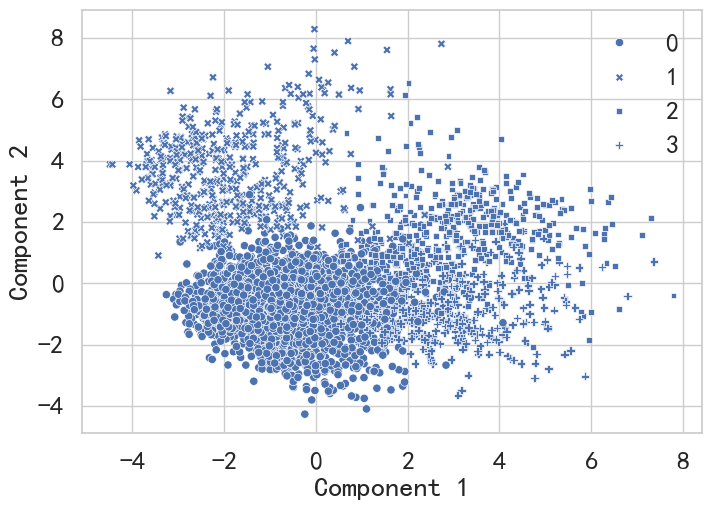

In [49]:
# HC
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    style=df["HC_Clusters"],
    palette="rainbow",
)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(generateFilePath("hcpca"), bbox_inches='tight')